---
## PART 5: PSEUDO-LABELING USING PRETRAINED TRANSFORMER
---

Generate labels using a pretrained transformer model.

**Important:** These are pseudo-labels, not human-annotated ground truth.

We use distilbert-base-uncased-finetuned-sms-spam-detection for classification.

# Install required packages


In [1]:
# Install required packages
!pip install pandas numpy nltk torch matplotlib datasets transformers tqdm -q


# Download NLTK data


In [2]:
# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('punkt-tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')


print("✓ All dependencies installed successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Error loading punkt-tab: Package 'punkt-tab' not found in
[nltk_data]     index
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✓ All dependencies installed successfully!


In [3]:
# =========================
# Standard Libraries
# =========================
import logging
import warnings

# =========================
# Data Handling
# =========================
import numpy as np
import pandas as pd

# =========================
# Data Visualization
# =========================
import matplotlib.pyplot as plt

# =========================
# Deep Learning
# =========================
import torch
from transformers import AutoTokenizer, pipeline
from datasets import Dataset



# =========================
# Configuration
# =========================
warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# =========================
# Environment Check
# =========================
print("✓ All libraries imported successfully!")
print(f"✓ PyTorch GPU available: {torch.cuda.is_available()}")

✓ All libraries imported successfully!
✓ PyTorch GPU available: True


---
## PART 1: LOAD DATASET
---

**Dataset Info:**
- Shape: (517401, 2)
- Columns: ['file', 'message']
- Each row contains raw email message including headers and body

In [4]:
print("Loading dataset...")
try:
    emails_df = pd.read_csv('../data/processed/emails_cleaned.csv')
    print(f"Dataset Loaded Successfully")
except FileNotFoundError:
    print("Dataset not found. Download from: https://www.kaggle.com/datasets/wcukierski/enron-email-dataset")

Loading dataset...
Dataset Loaded Successfully


count    118970.000000
mean         29.614004
std          18.731004
min           1.000000
25%          16.000000
50%          25.000000
75%          38.000000
max         269.000000
Name: subject_clean, dtype: float64


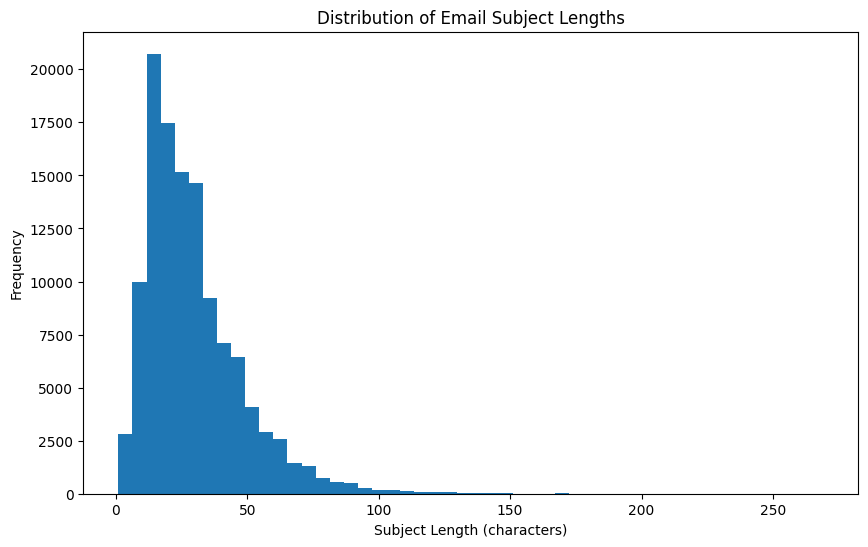

In [5]:

# Character lengths
lengths = (
    emails_df['subject_clean']
    .fillna("")
    .astype(str)
    .str.len()
)

print(lengths.describe())

# Distribution plot
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50)

plt.xlabel("Subject Length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Email Subject Lengths")

plt.show()

In [6]:
MODEL_NAME = "mariagrandury/distilbert-base-uncased-finetuned-sms-spam-detection"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, )

max_tokens = max(
    len(tokenizer.encode(str(text), truncation=False))
    for text in emails_df["subject_clean"].fillna("")
)

print(f"Maximum token length: {max_tokens}")

max_length = emails_df["subject_clean"].astype(str).str.len().max()

print(f"Maximum character length: {max_length}")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/333 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Maximum token length: 105
Maximum character length: 269


In [7]:
##  THIS CELL already runned on Colab to reduce time

# Clean texts FIRST
texts = (
    emails_df['subject_clean']
    .fillna("")
    .astype(str)
    .tolist()
)

dataset = Dataset.from_dict({
    "text": texts
})

classifier = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=0,
    dtype=torch.float16
)

with torch.inference_mode():
    results = classifier(
        texts,
        batch_size=256,
        truncation=True,
        max_length=max_tokens
    )

print(results[:5])

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'LABEL_0', 'score': 0.9975417852401733}, {'label': 'LABEL_0', 'score': 0.9984269142150879}, {'label': 'LABEL_0', 'score': 0.8446654081344604}, {'label': 'LABEL_0', 'score': 0.5678916573524475}, {'label': 'LABEL_0', 'score': 0.9365176558494568}]


In [8]:
emails_df["transformer_label"] = [
    r["label"] for r in results
]

emails_df["transformer_confidence"] = [
    float(r["score"]) for r in results
]

print(classifier.model.config.id2label)

{0: 'LABEL_0', 1: 'LABEL_1'}


In [9]:
label_map = {
    "LABEL_0": "ham",
    "LABEL_1": "spam"
}

emails_df["transformer_label"] = [
    label_map[r["label"]]
    for r in results
]

emails_df["transformer_confidence"] = [
    float(r["score"])
    for r in results
]

print(emails_df['transformer_label'].value_counts())

transformer_label
ham     102874
spam     16096
Name: count, dtype: int64


In [10]:
threshold = 0.65

emails_cleaned_labelled = emails_df[
    emails_df["transformer_confidence"] >= threshold
]

spam_percent = (
    (emails_cleaned_labelled['transformer_label'] == 'spam').mean() * 100
)

print(f"Spam percentage: {spam_percent:.2f}%")

Spam percentage: 11.44%


In [11]:
import os

# 2) Set your path (change folder/file name if you want)
folder_path = '../data/processed'
file_name = 'emails_cleaned_labelled.csv'
full_path = os.path.join(folder_path, file_name)

# 3) Create folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

# 4) Save DataFrame
emails_cleaned_labelled.to_csv(full_path, index=False, encoding='utf-8')

print(f"✅ Saved successfully to: {full_path}")

✅ Saved successfully to: ../data/processed/emails_cleaned_labelled.csv
